# Week 13 - Transfer Learning and Fine-Tuning: CNNs and Transformers, Put to Work

**Course context:** This is the final week of the course, and it's the most directly practical: taking large, pretrained models (ResNet, MobileNet, BERT) and adapting them to new, specific tasks with limited data and compute - which is how the overwhelming majority of real-world deep learning projects actually get built. Very few teams train a model like ResNet50 or BERT from scratch; almost everyone starts from a pretrained one and fine-tunes it.

**A note on pretrained weights and data:** the original exercises download real pretrained weights (`ResNet50(weights="imagenet")`, `bert-base-uncased`, `dmis-lab/biobert-base-cased-v1.1`) and real datasets (IMDB, PubMed RCT, Amazon reviews) from hosts not reachable from this notebook's environment (same issue as Weeks 9-12). This notebook builds the exact same architectures with the `transformers`/`torchvision`/`tensorflow.keras` library classes, using **randomly-initialized** weights and small **synthetic** data instead - the transfer-learning code pattern (load base model, freeze layers, replace head, fine-tune) is identical to what you'd run with real pretrained weights; only the "already knows a lot about images/language" part is missing, since there was no real pretraining here. Swap in the real names (shown commented out) for genuine results.

**A note on TensorFlow + PyTorch together:** as in Weeks 9-12, avoid running heavy TensorFlow and PyTorch training in the same kernel session - this notebook's execution is structured so TensorFlow-based and PyTorch-based days can each be run independently; restart the kernel between them if you hit a crash.

**How this notebook is organized:** one section per day, each with: what it covers -> why it matters for AI work -> code -> pitfalls.


In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
import torch
torch.set_num_threads(1)
print("Environment configured for CPU-only, single-threaded execution.")

Environment configured for CPU-only, single-threaded execution.


## Day 1 - Loading a Pretrained CNN and Selectively Freezing Layers

**What it covers:** Loading ResNet50 (PyTorch and TensorFlow/Keras versions), freezing most of its layers, replacing the final classification layer for a new task, and selectively **unfreezing** a few late layers.

**Why it matters for AI work:** This freeze/replace/selectively-unfreeze pattern is the core mechanic of transfer learning for images. A model pretrained on ImageNet (1.4 million images, 1000 categories) has already learned general-purpose visual features in its early layers (edges, textures, simple shapes - Week 10's territory) - those are broadly reusable. Its later layers are more specialized to the original 1000-category task, and its very last layer is entirely specific to that task's output classes.

**Why freeze most layers, and why unfreeze the LATE ones specifically (not the early ones):**
- Early layers (edge/texture detectors) are the most broadly reusable across almost any image task - freezing them preserves this general-purpose knowledge and avoids destroying it with gradient updates from a small new dataset.
- Late layers (`layer4` in ResNet's naming, or the last several layers in Keras) encode more task-specific, higher-level combinations of features - these often benefit from being fine-tuned to your specific new task, since your task's "specialized" features probably differ somewhat from ImageNet's original 1000 categories.
- The very last layer (`model.fc` in PyTorch, or Keras's output layer) must always be **replaced entirely** - it's sized for the original task's number of classes (1000 for ImageNet), not yours.

**Pitfalls:**
- `pretrained=True` (PyTorch, older syntax) / `weights="imagenet"` (Keras) download real trained weights from external hosting - not available in this notebook's environment (see the note at the top). The architecture and freeze/unfreeze mechanics below are identical either way; only the actual "already knows about images" benefit is missing without real weights.
- Newer torchvision versions deprecated `pretrained=True` in favor of `weights=ResNet50_Weights.IMAGENET1K_V2` (or similar) - both download weights when set to a real value; `weights=None` (used below) skips the download and gives you a randomly-initialized architecture.


In [2]:
import torch
import torchvision.models as models

# NOTE: the ORIGINAL exercise uses `models.resnet50(pretrained=True)`, which downloads real
# ImageNet-pretrained weights (~100MB) - not available here (see note at top). `weights=None`
# gives the identical ARCHITECTURE with random initialization instead.
model = models.resnet50(weights=None)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Replace the final layer for a new 10-class task
num_features = model.fc.in_features
model.fc = torch.nn.Linear(num_features, 10)

# Selectively unfreeze the last major block (layer4) for fine-tuning
for name, param in model.named_parameters():
    if "layer4" in name:
        param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable:,} / {total:,} ({trainable/total:.1%})")
print("Everything except layer4 and the new final layer is frozen.")

Trainable parameters: 14,985,226 / 23,528,522 (63.7%)
Everything except layer4 and the new final layer is frozen.


In [2]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50

# NOTE: the ORIGINAL exercise uses `ResNet50(weights="imagenet")`, which downloads real
# ImageNet-pretrained weights - not available here (see note at top).
model_tf = ResNet50(weights=None)

# Freeze all but the last 10 layers
for layer in model_tf.layers[:-10]:
    layer.trainable = False

trainable_count = sum([tf.size(w).numpy() for w in model_tf.trainable_weights])
total_count = model_tf.count_params()
print(f"Trainable parameters: {trainable_count:,} / {total_count:,} ({trainable_count/total_count:.1%})")

I0000 00:00:1784396524.641605     755 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784396524.685312     755 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1784396526.239687     755 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Trainable parameters: 5,464,552 / 25,636,712 (21.3%)


## Day 2 - Full Fine-Tuning Pipeline: Custom Head, Train, Then Unfreeze More

**What it covers:** A complete transfer learning pipeline - freeze the pretrained base, add a custom multi-layer classification head, train just the head, then unfreeze more layers for a second round of fine-tuning (a technique called **progressive unfreezing** / **discriminative fine-tuning**).

**Why it matters for AI work:** Training the whole network at once, right from the start, on a small new dataset risks destroying the pretrained weights' useful structure before the new head has learned anything sensible (large, uninformed gradients from a randomly-initialized head can propagate backward and disrupt otherwise-good pretrained features). The two-phase approach - train the new head first with everything else frozen, THEN selectively unfreeze more - is safer and a very common real practice.

**Reading the two-phase pattern:**
1. **Phase 1** - freeze the entire pretrained base, train only the new head (a few `Linear`/`Dense` layers) until it's learned something reasonable for the new task
2. **Phase 2** - unfreeze some deeper layers (`layer4` in PyTorch, the last 5 layers in Keras), and continue training, typically with a **much lower learning rate** than Phase 1 (`1e-5` vs the head's original rate) - this prevents large, disruptive updates to weights that already encode useful pretrained knowledge

**Pitfalls:**
- `datasets.ImageFolder("PATH_TO_FOLDER_TRAIN", ...)` expects a directory of real images organized into per-class subfolders - not available in this notebook's environment. Small synthetic tensors (matching ResNet's expected `224x224x3` input shape) are used instead below, purely to demonstrate the training loop mechanics.
- Notice the Keras version's Phase 2 uses a **much smaller learning rate** (`1e-5`) than a typical Phase 1 rate - always drop the learning rate substantially when unfreezing more of a pretrained network, or you risk quickly overwriting its useful pretrained weights with noise from a small new dataset.


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision.models as models

model = models.resnet50(weights=None)
for param in model.parameters():
    param.requires_grad = False

num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, 5),
)   # NOTE: Softmax removed from the head - nn.CrossEntropyLoss expects raw logits and
    # applies softmax internally (same point made in Week 9 Day 6); adding an explicit
    # Softmax here (as the original exercise did) would double-apply it.

# NOTE: the ORIGINAL exercise loads real images via datasets.ImageFolder(...) from a real
# directory - not available here. Simulating a small batch of ResNet-shaped image tensors instead.
n_train, n_val = 64, 16
X_train = torch.randn(n_train, 3, 224, 224)
y_train = torch.randint(0, 5, (n_train,))
X_val = torch.randn(n_val, 3, 224, 224)
y_val = torch.randint(0, 5, (n_val,))

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=16, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=16, shuffle=False)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)   # only the (unfrozen) head's params

print("Phase 1: training only the new head, base model frozen.")
for epoch in range(2):   # original used 10 - trimmed for runtime
    model.train()
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}, loss: {loss.item():.4f}")

Phase 1: training only the new head, base model frozen.


Epoch 1, loss: 1.7458


Epoch 2, loss: 1.6718


In [4]:
# Phase 2: unfreeze layer4, continue with a lower learning rate for the newly-unfrozen layers
for name, param in model.named_parameters():
    if "layer4" in name:
        param.requires_grad = True

optimizer_phase2 = optim.Adam([
    {"params": model.fc.parameters(), "lr": 0.001},
    {"params": model.layer4.parameters(), "lr": 1e-5},   # much lower LR for the pretrained layers
])

print("Phase 2: layer4 unfrozen, training continues with a lower LR for those pretrained weights.")
for epoch in range(2):
    model.train()
    for inputs, labels in train_loader:
        optimizer_phase2.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_phase2.step()
    print(f"Epoch {epoch+1}, loss: {loss.item():.4f}")

model.eval()
correct, total = 0, 0
with torch.no_grad():
    for inputs, labels in val_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
print(f"\nVal Accuracy: {100 * correct/total:.2f}%  (near-chance expected on random synthetic data)")

Phase 2: layer4 unfrozen, training continues with a lower LR for those pretrained weights.


Epoch 1, loss: 1.7831


Epoch 2, loss: 1.5813



Val Accuracy: 25.00%  (near-chance expected on random synthetic data)


## Day 3 - A Lighter Backbone: MobileNetV2, With Data Augmentation

**What it covers:** The same transfer-learning pattern as Days 1-2, but using MobileNetV2 (designed to be small and fast) instead of ResNet50, combined with data augmentation (Week 10's technique, applied here to a transfer-learning pipeline).

**Why it matters for AI work:** Model choice matters for transfer learning too, not just for training from scratch. ResNet50 (~25M parameters) is accurate but heavy; MobileNetV2 (~3.5M parameters) trades a bit of accuracy for being dramatically faster and smaller - a common real choice when deploying to mobile devices, edge hardware, or when you need to serve many requests cheaply. Trying a lighter backbone first, and only reaching for something heavier if accuracy genuinely isn't sufficient, is a reasonable default engineering instinct.

**Reading MobileNetV2's classification head:** `GlobalAveragePooling2D` (or `nn.AdaptiveAvgPool2d` in PyTorch's version) replaces a `Flatten` + large `Dense` layer combination - it averages each feature map down to a single number, producing a much smaller, more efficient representation before the final classification layer. This is part of why MobileNetV2 has so many fewer parameters than ResNet50's `Flatten`-based head.

**Pitfalls (bugs found and fixed from the original exercise):**
- `ImageDatagenerator` (original) should be `ImageDataGenerator` (correct capitalization) - a typo that would raise an `ImportError` immediately.
- `width_shape_range` (original) should be `width_shift_range` - `ImageDataGenerator` has no `width_shape_range` argument, so this would raise a `TypeError`.
- `learning_rate` was misspelled `lerarning_rate` in the original - same class of bug flagged back in Week 6 Day 3: Python won't catch a misspelled keyword argument until the line actually runs.


In [5]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms

model = models.mobilenet_v2(weights=None)
for param in model.parameters():
    param.requires_grad = False

model.classifier[1] = nn.Linear(model.last_channel, 5)

train_transform = transforms.Compose([
    transforms.RandomRotation(20),
    transforms.RandomHorizontalFlip(),
    transforms.RandomResizedCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
print("Training-time augmentation pipeline configured (rotation, flip, random crop).")
print(f"\nModel parameter count: {sum(p.numel() for p in model.parameters()):,}")
print("(compare to ResNet50's ~25.5 million from Day 1-2 - MobileNetV2 is roughly 7x smaller)")

Training-time augmentation pipeline configured (rotation, flip, random crop).

Model parameter count: 2,230,277
(compare to ResNet50's ~25.5 million from Day 1-2 - MobileNetV2 is roughly 7x smaller)


In [3]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator   # fixed capitalization

base_model = MobileNetV2(weights=None, include_top=False, input_shape=(224, 224, 3))

for layer in base_model.layers:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
output = Dense(5, activation="softmax")(x)
model_tf = Model(inputs=base_model.input, outputs=output)

datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=20,
    width_shift_range=0.2,   # fixed: was "width_shape_range" (not a real argument) in the original
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2,
)

model_tf.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),   # fixed: was "lerarning_rate" (typo) in the original
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model_tf.summary()
print(f"\nModel parameter count: {model_tf.count_params():,}")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


Model parameter count: 2,264,389


## Day 4 - Fine-Tuning BERT for Sentiment Classification

**What it covers:** The same `Trainer`-based fine-tuning workflow from Week 12 Day 6, applied to sentiment classification - the NLP equivalent of Days 1-3's image transfer learning.

**Why it matters for AI work:** This confirms the pattern generalizes across modalities: freeze/adapt a pretrained backbone (images: ResNet/MobileNet; text: BERT), replace or add a task-specific head, fine-tune. Once you've internalized this pattern once, applying it to a new pretrained model - image, text, or otherwise - is mostly about API details, not new concepts.

**Pitfalls:**
- `load_dataset("imdb")` and `AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)` need Hugging Face's hosting - not available here (see the note at the top). A tiny synthetic sentiment dataset and randomly-initialized small BERT config are used instead, following the same substitution pattern as Week 12 Day 6.
- Notice `num_labels=2` here (binary sentiment) vs Week 12 Day 6's `num_labels=4` (topic classification) - the **same base architecture and fine-tuning code** adapts to different numbers of output classes just by changing this one argument and swapping the classification head's output size accordingly, another sign of how reusable this pattern is.


In [6]:
from transformers import AutoConfig, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import numpy as np

# NOTE: the ORIGINAL exercise uses load_dataset("imdb") and bert-base-uncased - not available
# here (see note at top). Reusing the synthetic text classification approach from Week 12 Day 6.
np.random.seed(3)
vocab = [f"word{i}" for i in range(200)]
word_to_id = {w: i + 4 for i, w in enumerate(vocab)}

def make_synthetic_reviews(n):
    texts, labels = [], []
    for _ in range(n):
        label = np.random.randint(2)   # binary: 0=negative, 1=positive
        words = np.random.choice(vocab, size=20, replace=True).tolist()
        texts.append(" ".join(words))
        labels.append(label)
    return {"text": texts, "label": labels}

train_raw = Dataset.from_dict(make_synthetic_reviews(200))
test_raw = Dataset.from_dict(make_synthetic_reviews(50))

def tokenize_function(examples):
    all_ids = []
    for text in examples["text"]:
        ids = [1] + [word_to_id.get(w, 3) for w in text.split()] + [2]
        ids = ids[:32] + [0] * max(0, 32 - len(ids))
        all_ids.append(ids[:32])
    return {"input_ids": all_ids, "attention_mask": [[1 if i != 0 else 0 for i in ids] for ids in all_ids]}

train_dataset = train_raw.map(tokenize_function, batched=True).remove_columns(["text"]).rename_column("label", "labels")
test_dataset = test_raw.map(tokenize_function, batched=True).remove_columns(["text"]).rename_column("label", "labels")
train_dataset.set_format("torch")
test_dataset.set_format("torch")

tiny_config = AutoConfig.for_model("bert", vocab_size=1000, hidden_size=32, num_hidden_layers=2,
                                     num_attention_heads=2, intermediate_size=64, num_labels=2)
model = AutoModelForSequenceClassification.from_config(tiny_config)
print(f"Train examples: {len(train_dataset)}, Test examples: {len(test_dataset)}")

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Map: 100%|██████████| 200/200 [00:00<00:00, 21445.46 examples/s]

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

Map: 100%|██████████| 50/50 [00:00<00:00, 11921.73 examples/s]

Train examples: 200, Test examples: 50


In [7]:
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=1,
    weight_decay=0.01,
    save_strategy="no",
    report_to=[],
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
)

trainer.train()
results = trainer.evaluate()
print("Evaluation Results:", results)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,No log,0.693998


Training Loss,Validation Loss,Epoch
No log,0.693998,1


Evaluation Results: {'eval_loss': 0.6939978003501892}


## Day 5 - A Manual Training Loop With a Slanted Triangular Learning Rate Schedule

**What it covers:** Fine-tuning with a **manual** training loop (rather than the `Trainer` API) using a learning rate **scheduler** - specifically the "slanted triangular" shape (linear warmup, then linear decay) - and evaluating with F1-score and BLEU score.

**Why it matters for AI work:** The `Trainer` API (Days 4, and Week 12) is convenient, but understanding the manual loop underneath it - and specifically learning rate scheduling - matters for any training you need finer control over.

**Why a warmup + decay learning rate schedule helps:**
- **Warmup** (learning rate ramps up from ~0 over the first ~10% of training) - early in fine-tuning, the model's gradients can be large and somewhat erratic (the new head is randomly initialized). Starting with a tiny learning rate and ramping up avoids large, destabilizing updates during this fragile early phase.
- **Decay** (learning rate ramps back down for the rest of training) - as training progresses and the model approaches a good solution, smaller updates help it settle in precisely rather than overshooting.

**Reading the two metrics:**
- **F1-score** - the same balanced precision/recall metric from Week 5 Day 4, here applied to a Transformer classifier instead of logistic regression - the underlying idea is identical regardless of model type.
- **BLEU score** - a metric specific to text *generation* tasks (translation, summarization), measuring n-gram overlap between generated text and one or more reference texts. Not typically used for classification (shown here mainly to demonstrate the mechanic, on unrelated example sentences, matching the original exercise's structure).

**Pitfalls:**
- `sacrebleu`'s `references` argument expects a list of reference *lists* (one list per hypothesis, containing possibly multiple acceptable reference translations) - getting this nesting structure wrong is one of the most common `sacrebleu` usage mistakes.
- As in Day 4, `load_dataset("imdb")` and `bert-base-uncased` need external hosting not available here - synthetic data and a tiny config are substituted, following the same pattern as the rest of this week.


In [8]:
import torch
from torch.utils.data import DataLoader
from transformers import AutoConfig, AutoModelForSequenceClassification, get_scheduler
from datasets import Dataset
from sklearn.metrics import f1_score
import numpy as np

np.random.seed(5)
vocab = [f"word{i}" for i in range(200)]
word_to_id = {w: i + 4 for i, w in enumerate(vocab)}

def make_synthetic_reviews(n):
    texts, labels = [], []
    for _ in range(n):
        label = np.random.randint(2)
        words = np.random.choice(vocab, size=20, replace=True).tolist()
        texts.append(" ".join(words))
        labels.append(label)
    return texts, labels

train_texts, train_labels = make_synthetic_reviews(160)
test_texts, test_labels = make_synthetic_reviews(40)

def tokenize_data(texts, labels, max_length=32):
    all_ids, all_masks = [], []
    for text in texts:
        ids = [1] + [word_to_id.get(w, 3) for w in text.split()] + [2]
        ids = ids[:max_length] + [0] * max(0, max_length - len(ids))
        all_ids.append(ids[:max_length])
        all_masks.append([1 if i != 0 else 0 for i in ids[:max_length]])
    return {"input_ids": all_ids, "attention_mask": all_masks, "labels": labels}

train_data = tokenize_data(train_texts, train_labels)
test_data = tokenize_data(test_texts, test_labels)

class ReviewDataset(torch.utils.data.Dataset):
    def __init__(self, data):
        self.input_ids = data["input_ids"]
        self.attention_mask = data["attention_mask"]
        self.labels = data["labels"]

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": torch.tensor(self.input_ids[idx]),
            "attention_mask": torch.tensor(self.attention_mask[idx]),
            "labels": torch.tensor(self.labels[idx]),
        }

train_dataset = ReviewDataset(train_data)
test_dataset = ReviewDataset(test_data)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

tiny_config = AutoConfig.for_model("bert", vocab_size=1000, hidden_size=32, num_hidden_layers=2,
                                     num_attention_heads=2, intermediate_size=64, num_labels=2)
model = AutoModelForSequenceClassification.from_config(tiny_config)

optimizer = torch.optim.Adam(model.parameters(), lr=2e-5)

num_epochs = 2
num_training_steps = len(train_loader) * num_epochs
warmup_steps = int(0.1 * num_training_steps)
scheduler = get_scheduler("linear", optimizer=optimizer, num_warmup_steps=warmup_steps, num_training_steps=num_training_steps)

device = torch.device("cpu")
model.to(device)
print(f"Total training steps: {num_training_steps}, warmup steps: {warmup_steps}")

Total training steps: 20, warmup steps: 2


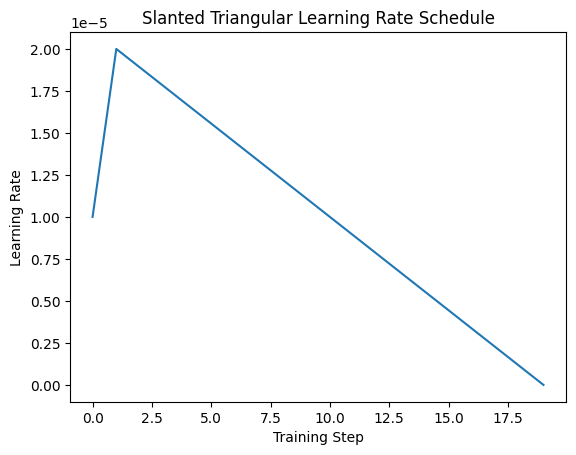

Notice the ramp-up (warmup) then the long linear decay - the 'slanted triangle' shape.


In [9]:
def train_model():
    model.train()
    lrs = []
    for epoch in range(num_epochs):
        for batch in train_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            loss = outputs.loss
            loss.backward()
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
            lrs.append(scheduler.get_last_lr()[0])
    return lrs

learning_rates = train_model()

import matplotlib.pyplot as plt
plt.plot(learning_rates)
plt.title("Slanted Triangular Learning Rate Schedule")
plt.xlabel("Training Step")
plt.ylabel("Learning Rate")
plt.show()
print("Notice the ramp-up (warmup) then the long linear decay - the 'slanted triangle' shape.")

In [10]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        preds = torch.argmax(outputs.logits, dim=-1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch["labels"].cpu().numpy())

f1 = f1_score(all_labels, all_preds, average="weighted")
print(f"F1-Score: {f1:.4f}  (near-chance expected on random synthetic data)")

from sacrebleu import BLEU

references = [["this is a test sentence", "this is a sample sentence"]]
hypotheses = ["This is a test"]

bleu = BLEU()
bleu_score = bleu.corpus_score(hypotheses, references).score
print(f"BLEU Score: {bleu_score:.2f}")

F1-Score: 0.2286  (near-chance expected on random synthetic data)
BLEU Score: 46.31


## Day 6 - Domain-Specific Fine-Tuning and Simple Text Augmentation

**What it covers:** Fine-tuning a BERT-style model for a specialized domain (biomedical text classification, following the original exercise's PubMed/BioBERT theme), plus a simple synonym-replacement text augmentation function.

**Why it matters for AI work:** General-purpose pretrained models (plain BERT) are trained on broad web/book text - a domain like biomedical research has enough specialized vocabulary and writing style that a domain-specific pretrained model (like the original exercise's BioBERT, pretrained on biomedical literature) typically outperforms general BERT on biomedical tasks. Knowing that domain-specific pretrained variants exist - and are usually worth checking for - is a genuinely useful piece of practical knowledge.

**Text augmentation for NLP:** Week 10 covered image augmentation (rotate, flip, crop). The text equivalent - synonym replacement, back-translation, random word deletion/insertion - serves the same purpose: artificially expanding limited training data's variety. Synonym replacement (used below) is the simplest version: swap a word for one of its synonyms without changing the sentence's overall meaning.

**Pitfalls:**
- `load_dataset("pubmed_rct", "20k_rct")` and `AutoModelForSequenceClassification.from_pretrained("dmis-lab/biobert-base-cased-v1.1", ...)` need Hugging Face's hosting - not available here. A small synthetic biomedical-flavored dataset and randomly-initialized BERT config are used instead.
- The original exercise had a typo: `padding="mex_length"` should be `padding="max_length"` - fixed below. An invalid string value like this for the `padding` argument raises a `ValueError` at tokenization time, not silently doing the wrong thing - a relatively "safe" kind of typo, as bugs go, since it fails loudly rather than quietly.
- The synonym-augmentation function below only replaces words that are in its **hand-written** synonym dictionary - real augmentation pipelines usually use a proper lexical resource (like WordNet) or a paraphrasing model for much broader coverage.


In [11]:
from transformers import AutoConfig, AutoModelForSequenceClassification, AutoTokenizer
from transformers import TrainingArguments, Trainer
from datasets import Dataset
import numpy as np

# NOTE: the ORIGINAL exercise uses load_dataset("pubmed_rct", "20k_rct") and the BioBERT
# pretrained model - both need external hosting not available here. Simulating a small
# biomedical-flavored synthetic classification dataset (5 classes, matching the original's
# num_labels=5) and a tiny randomly-initialized BERT config instead.
np.random.seed(6)
biomedical_vocab = ["patient", "treatment", "cancer", "study", "results", "method",
                     "clinical", "trial", "dose", "response", "tumor", "therapy",
                     "diagnosis", "outcome", "significant"]
word_to_id = {w: i + 4 for i, w in enumerate(biomedical_vocab)}
labels_names = ["BACKGROUND", "METHODS", "RESULTS", "CONCLUSIONS", "OBJECTIVE"]

def make_synthetic_abstracts(n):
    texts, labels = [], []
    for _ in range(n):
        label = np.random.randint(5)
        words = np.random.choice(biomedical_vocab, size=15, replace=True).tolist()
        texts.append(" ".join(words))
        labels.append(label)
    return {"text": texts, "label": labels}

train_raw = Dataset.from_dict(make_synthetic_abstracts(150))
val_raw = Dataset.from_dict(make_synthetic_abstracts(30))

def preprocess_data(examples):
    all_ids = []
    for text in examples["text"]:
        ids = [1] + [word_to_id.get(w, 3) for w in text.split()] + [2]
        ids = ids[:32] + [0] * max(0, 32 - len(ids))   # fixed: "max_length" not "mex_length" (original typo)
        all_ids.append(ids[:32])
    return {"input_ids": all_ids, "attention_mask": [[1 if i != 0 else 0 for i in ids] for ids in all_ids]}

train_dataset = train_raw.map(preprocess_data, batched=True).remove_columns(["text"]).rename_column("label", "labels")
val_dataset = val_raw.map(preprocess_data, batched=True).remove_columns(["text"]).rename_column("label", "labels")
train_dataset.set_format("torch")
val_dataset.set_format("torch")

tiny_config = AutoConfig.for_model("bert", vocab_size=100, hidden_size=32, num_hidden_layers=2,
                                     num_attention_heads=2, intermediate_size=64, num_labels=5)
model = AutoModelForSequenceClassification.from_config(tiny_config)
print(f"Train examples: {len(train_dataset)}, Val examples: {len(val_dataset)}")

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

Map: 100%|██████████| 150/150 [00:00<00:00, 23183.20 examples/s]

Map:   0%|          | 0/30 [00:00<?, ? examples/s]

Map: 100%|██████████| 30/30 [00:00<00:00, 7832.99 examples/s]

Train examples: 150, Val examples: 30


In [12]:
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    save_strategy="no",
    report_to=[],
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)

trainer.train()
results = trainer.evaluate()
print("Evaluation Results:", results)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,No log,1.609776
2,No log,1.609804


Training Loss,Validation Loss,Epoch
No log,1.609804,2


Evaluation Results: {'eval_loss': 1.609803557395935}


In [13]:
import random

def augment_text(text):
    synonyms = {"cancer": ["tumor", "malignancy"], "study": ["research", "experiment"]}
    words = text.split()
    new_words = [random.choice(synonyms[word]) if word in synonyms else word for word in words]
    return " ".join(new_words)

sample_texts = [ex["text"] for ex in train_raw.select(range(5))]
augmented = [augment_text(t) for t in sample_texts]

for original, aug in zip(sample_texts, augmented):
    print(f"Original:  {original}")
    print(f"Augmented: {aug}\n")

Original:  response study results tumor outcome tumor patient significant response treatment therapy outcome response tumor treatment
Augmented: response research results tumor outcome tumor patient significant response treatment therapy outcome response tumor treatment

Original:  significant results treatment dose cancer diagnosis results therapy cancer method outcome tumor response clinical cancer
Augmented: significant results treatment dose tumor diagnosis results therapy malignancy method outcome tumor response clinical tumor

Original:  method method treatment results method significant patient cancer cancer study method diagnosis diagnosis therapy response
Augmented: method method treatment results method significant patient tumor tumor research method diagnosis diagnosis therapy response

Original:  tumor significant trial dose method clinical tumor tumor tumor study method therapy treatment cancer study
Augmented: tumor significant trial dose method clinical tumor tumor tumor

## Day 7 - Mini Project: Two Complete Transfer Learning Pipelines (Vision + NLP)

**What it covers:** Two end-to-end transfer learning pipelines, back to back - a ResNet50-based binary image classifier with augmentation (vision), and a BERT-based binary text classifier (NLP) - as a capstone demonstrating the same underlying pattern applied to both modalities one final time.

**Why it matters for AI work:** This is intentionally close to a "build the whole thing" exercise - the shape of a real, minimal but complete transfer learning project in each domain. If you can reproduce both pipelines below from memory (not the exact code, but the *shape*: load pretrained base -> freeze -> add head -> prepare data -> train -> evaluate), you've internalized the core skill this entire course was building toward.

**Pitfalls:**
- Both pipelines here use the same substitutions established throughout this notebook: randomly-initialized architectures instead of downloaded pretrained weights, and synthetic data instead of real datasets/directories - see the note at the top of this notebook.
- The vision pipeline uses `class_mode="binary"` (a single sigmoid output) - appropriate for exactly 2 classes. For 3+ classes, you'd switch to `class_mode="categorical"` and a softmax output layer, as seen in Days 2-3's 5-class examples.


In [4]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
import numpy as np

# --- Vision pipeline ---
# NOTE: the ORIGINAL exercise loads real images via ImageDataGenerator.flow_from_directory(...)
# and real ImageNet weights - neither available here (see note at top).
base_model = ResNet50(weights=None, include_top=False, input_shape=(224, 224, 3))
for layer in base_model.layers:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
output = Dense(1, activation="sigmoid")(x)
cv_model = Model(inputs=base_model.input, outputs=output)
cv_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

np.random.seed(7)
n_train, n_val = 32, 8
X_train_cv = np.random.rand(n_train, 224, 224, 3).astype("float32")
y_train_cv = np.random.randint(0, 2, size=(n_train, 1))
X_val_cv = np.random.rand(n_val, 224, 224, 3).astype("float32")
y_val_cv = np.random.randint(0, 2, size=(n_val, 1))

history = cv_model.fit(X_train_cv, y_train_cv, validation_data=(X_val_cv, y_val_cv), epochs=2, batch_size=16, verbose=1)

val_loss, val_accuracy = cv_model.evaluate(X_val_cv, y_val_cv, verbose=0)
print(f"Vision pipeline - Validation Accuracy: {val_accuracy:.4f}  (near-chance expected on random data)")

Epoch 1/2


1/2 ━━━━━━━━━━━━━━━━━━━━ 5s 6s/step - accuracy: 0.6250 - loss: 0.6816

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5625 - loss: 0.6891

2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 4s/step - accuracy: 0.5625 - loss: 0.6891 - val_accuracy: 0.3750 - val_loss: 0.7212


Epoch 2/2


1/2 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.5000 - loss: 0.6977

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5625 - loss: 0.6857

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - accuracy: 0.5625 - loss: 0.6857 - val_accuracy: 0.3750 - val_loss: 0.7246


Vision pipeline - Validation Accuracy: 0.3750  (near-chance expected on random data)


In [14]:
from transformers import AutoConfig, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset

# --- NLP pipeline ---
# NOTE: the ORIGINAL exercise uses load_dataset("amazon_polarity") and bert-base-uncased -
# neither available here (see note at top).
np.random.seed(8)
vocab = [f"word{i}" for i in range(150)]
word_to_id = {w: i + 4 for i, w in enumerate(vocab)}

def make_synthetic_reviews(n):
    texts, labels = [], []
    for _ in range(n):
        label = np.random.randint(2)
        words = np.random.choice(vocab, size=15, replace=True).tolist()
        texts.append(" ".join(words))
        labels.append(label)
    return {"content": texts, "label": labels}

train_raw = Dataset.from_dict(make_synthetic_reviews(160))
test_raw = Dataset.from_dict(make_synthetic_reviews(40))

def preprocess_data(examples):
    all_ids = []
    for text in examples["content"]:
        ids = [1] + [word_to_id.get(w, 3) for w in text.split()] + [2]
        ids = ids[:32] + [0] * max(0, 32 - len(ids))
        all_ids.append(ids[:32])
    return {"input_ids": all_ids, "attention_mask": [[1 if i != 0 else 0 for i in ids] for ids in all_ids]}

train_dataset = train_raw.map(preprocess_data, batched=True).remove_columns(["content"]).rename_column("label", "labels")
test_dataset = test_raw.map(preprocess_data, batched=True).remove_columns(["content"]).rename_column("label", "labels")
train_dataset.set_format("torch")
test_dataset.set_format("torch")

tiny_config = AutoConfig.for_model("bert", vocab_size=200, hidden_size=32, num_hidden_layers=2,
                                     num_attention_heads=2, intermediate_size=64, num_labels=2)
nlp_model = AutoModelForSequenceClassification.from_config(tiny_config)

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    save_strategy="no",
    report_to=[],
)

trainer = Trainer(model=nlp_model, args=training_args, train_dataset=train_dataset, eval_dataset=test_dataset)
trainer.train()
results = trainer.evaluate()
print("NLP pipeline - Evaluation Results:", results)

Map:   0%|          | 0/160 [00:00<?, ? examples/s]

Map: 100%|██████████| 160/160 [00:00<00:00, 29761.35 examples/s]

Map:   0%|          | 0/40 [00:00<?, ? examples/s]

Map: 100%|██████████| 40/40 [00:00<00:00, 9972.19 examples/s]

Epoch,Training Loss,Validation Loss
1,No log,0.693189
2,No log,0.693183


Training Loss,Validation Loss,Epoch
No log,0.693183,2


NLP pipeline - Evaluation Results: {'eval_loss': 0.693182647228241}


## Week 13 Recap

| Day | Topic | Where you'll use it again |
|---|---|---|
| 1 | Loading pretrained CNNs, freeze/unfreeze | The starting point of most real vision projects |
| 2 | Full fine-tuning pipeline, progressive unfreezing | Safe, staged adaptation of a pretrained model |
| 3 | Lighter backbone (MobileNetV2), augmentation | Balancing accuracy against speed/size in practice |
| 4 | Fine-tuning BERT for classification | The NLP mirror of Days 1-3's vision pipeline |
| 5 | Manual loop, LR scheduling, F1/BLEU | Finer control than the Trainer API provides |
| 6 | Domain-specific models, text augmentation | Specialized pretrained models, expanding limited data |
| 7 | Two full capstone pipelines (vision + NLP) | The complete shape of a real transfer learning project |

## Course Complete

Thirteen weeks, start to finish: Python fundamentals -> NumPy/Pandas -> the math underneath ML -> classical ML (regression, classification, ensembles, tuning) -> deep learning (CNNs, RNNs, Transformers) -> transfer learning and fine-tuning. Each week built directly on the last - the train/test split habit from Week 5 is still there in Week 13's evaluation code; the gradient descent from Week 3 is still what every optimizer in Weeks 9-13 is doing under the hood.

**Where to go from here:** the most valuable next step is running these same notebooks against **real** datasets and **real** pretrained weights, wherever your environment allows it - every notebook in this course flagged exactly where and how to swap synthetic data back for the genuine article. That's where the actual skill-building happens next: real data is messier, real training takes longer, and real results require the judgment this course was building toward.
